In [1]:
import os, sys
import copy
import glob
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision import transforms
import matplotlib.pyplot as plt
import cv2
import imageio
from tqdm.notebook import tqdm
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# # for colab only  changes
# from google.colab import drive
# # If this fails in VS Code, check your "Jupyter" output tab for a URL to click!
# if not os.path.exists('/content/drive'):
#     drive.mount('/content/drive')

# # 2. Unzip Dataset (Only if not already unzipped)
# # I added a check so you don't waste time unzipping every time you restart the kernel
# if not os.path.exists("/content/dataset"):
#     print("Unzipping dataset... this may take a moment.")
#     !unzip -q "/content/drive/MyDrive/Generative_Models_714/term_project/dataset.zip" -d "/content/dataset"
#     print("Unzipping complete.")
# else:
#     print("Dataset already unzipped.")

# # 3. Add Source Code to Path
# project_path = "/content/drive/MyDrive/Generative_Models_714/term_project/src"

# if project_path not in sys.path:
#     sys.path.append(project_path)
#     print(f"Added {project_path} to sys.path")

# # 4. Verification
# # Try importing one of your scripts to confirm it works
# try:
#     import diffusion # Replace with an actual script name from your folder
#     print("Import successful!")
# except ImportError as e:
#     print(f"Import failed: {e}")



'expandable_segments:True'

In [2]:
# Config: paths and hyperparameters
import os
from dataclasses import dataclass

# Set your dataset root that contains: rgb/, depth/, mask/ (256x256 each)
DATASET_ROOT = "/home/cago/MMI_714_generative_models/term_project/dataset/cleargrasp-dataset-train-resized/"
#DATASET_ROOT = "/content/drive/MyDrive/Generative_Models_714/term_project/dataset/cleargrasp-dataset-train-resized/"
RGB_DIR = "rgb-imgs"
DEPTH_DIR = "depth-imgs-rectified"
MASK_DIR = "segmentation-masks"

# Depth range in meters for normalization to [-1,1]
DEPTH_MINMAX = (0.0, 5.0)

# Noise parameters (normalized depth space [-1,1])
SIGMA_MASK = 0.08     # heavy noise on transparent regions
SIGMA_GLOBAL = 0.01   # light noise everywhere

# Training
BATCH_SIZE = 256  # lowered to fit 8GB VRAM at 128x128
LR = 1e-4
EPOCHS = 50            # increase for real training
TIMESTEPS = 1000
NUM_WORKERS = 4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = True if DEVICE == "cuda" else False


In [3]:
# Imports and dataset/dataloaders
import torch
from torch.utils.data import DataLoader
from diffusion import GaussianDiffusion, DiffusionConfig
from conditional_unet_depth import ConditionalUNetDepth
from data_pipeline import DepthInpaintDataset, DepthDataConfig
from guidance_maps import GuidanceConfig

# Prepare datasets for optical and geometric branches
# Using pre-computed canny guidance maps from map_from_train_set.py
gcfg = GuidanceConfig()
IMG_SIZE = (128, 128)  # lowered resolution to fit 8GB VRAM

cfg_opt = DepthDataConfig(
    root=DATASET_ROOT, rgb_dir=RGB_DIR, depth_dir=DEPTH_DIR, mask_dir=MASK_DIR,
    size=IMG_SIZE, depth_minmax=DEPTH_MINMAX,
    sigma_mask=SIGMA_MASK, sigma_global=SIGMA_GLOBAL,
    branch="optical", include_guidance=True,
    # Pre-computed guidance maps (run map_from_train_set.py --edge-detector canny first)
    guidance_optical_dir="guidance-optical-mda",
    guidance_geometric_dir="guidance-geometric-mrgb",
    use_precomputed_guidance=True,  # Use pre-computed maps (much faster!)
)
cfg_geo = DepthDataConfig(
    root=DATASET_ROOT, rgb_dir=RGB_DIR, depth_dir=DEPTH_DIR, mask_dir=MASK_DIR,
    size=IMG_SIZE, depth_minmax=DEPTH_MINMAX,
    sigma_mask=SIGMA_MASK, sigma_global=SIGMA_GLOBAL,
    branch="geometric", include_guidance=True,
    guidance_optical_dir="guidance-optical-mda",
    guidance_geometric_dir="guidance-geometric-mrgb",
    use_precomputed_guidance=True,
)

ds_opt = DepthInpaintDataset(cfg_opt, gcfg)
ds_geo = DepthInpaintDataset(cfg_geo, gcfg)

dl_opt = DataLoader(ds_opt, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
dl_geo = DataLoader(ds_geo, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)


[INFO] Using pre-computed optical guidance maps from 'guidance-optical-mda/'
[INFO] Using pre-computed geometric guidance maps from 'guidance-geometric-mrgb/'


In [4]:
# Verify that RGB, depth, and mask paths are correctly paired within each class
print(f"Total samples: {len(ds_opt)}")
print("\n--- Checking a few sample paths to verify correct pairing ---")
for i in [0, 1000, 20000, 30000, 40000]:
    if i < len(ds_opt):
        print(f"\nSample {i}:")
        print(f"  RGB:   {ds_opt.rgb_paths[i]}")
        print(f"  Depth: {ds_opt.depth_paths[i]}")
        print(f"  Mask:  {ds_opt.mask_paths[i]}")
        # Extract class folder name to verify they match
        rgb_class = ds_opt.rgb_paths[i].split("/")[-3]
        depth_class = ds_opt.depth_paths[i].split("/")[-3]
        mask_class = ds_opt.mask_paths[i].split("/")[-3]
        match = "✓ MATCH" if rgb_class == depth_class == mask_class else "✗ MISMATCH!"
        print(f"  Class folders: RGB={rgb_class}, Depth={depth_class}, Mask={mask_class} {match}")

Total samples: 45454

--- Checking a few sample paths to verify correct pairing ---

Sample 0:
  RGB:   /home/cago/MMI_714_generative_models/term_project/dataset/cleargrasp-dataset-train-resized/cup-with-waves-train/rgb-imgs/000000000-rgb.jpg
  Depth: /home/cago/MMI_714_generative_models/term_project/dataset/cleargrasp-dataset-train-resized/cup-with-waves-train/depth-imgs-rectified/000000000-depth-rectified.exr
  Mask:  /home/cago/MMI_714_generative_models/term_project/dataset/cleargrasp-dataset-train-resized/cup-with-waves-train/segmentation-masks/000000000-segmentation-mask.png
  Class folders: RGB=cup-with-waves-train, Depth=cup-with-waves-train, Mask=cup-with-waves-train ✓ MATCH

Sample 1000:
  RGB:   /home/cago/MMI_714_generative_models/term_project/dataset/cleargrasp-dataset-train-resized/cup-with-waves-train/rgb-imgs/000001000-rgb.jpg
  Depth: /home/cago/MMI_714_generative_models/term_project/dataset/cleargrasp-dataset-train-resized/cup-with-waves-train/depth-imgs-rectified/0000

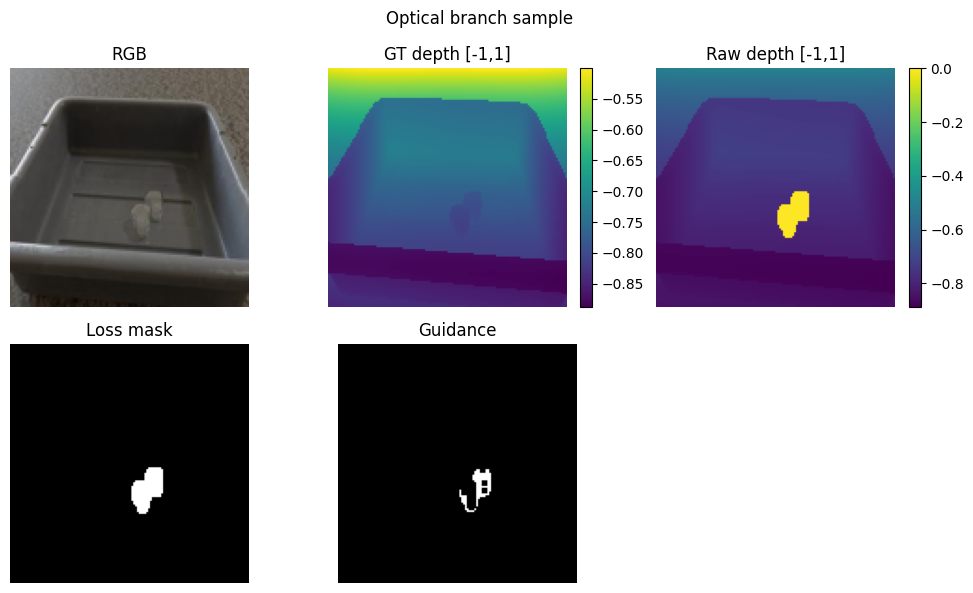

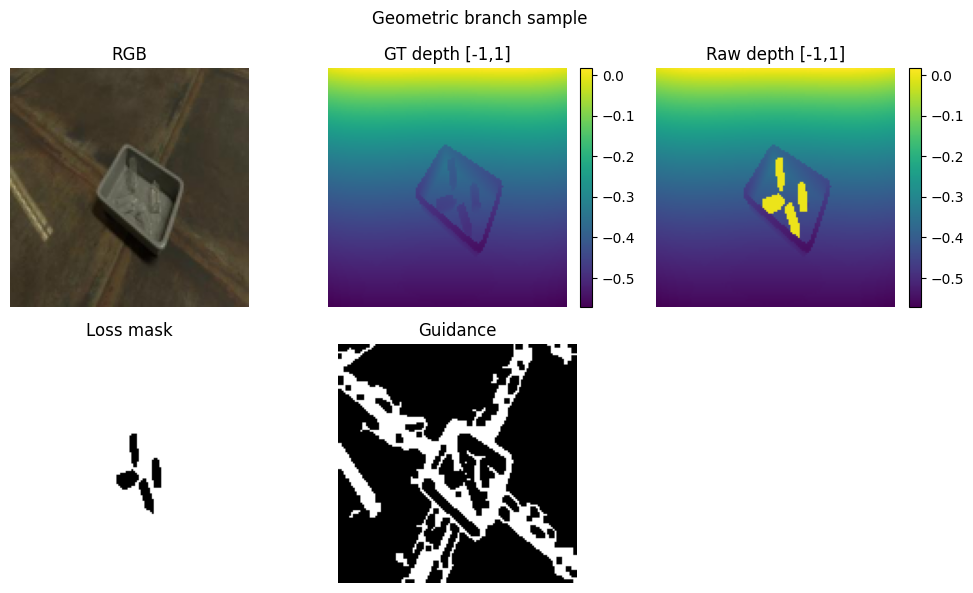

In [5]:
# Visualize a sample from each branch
import matplotlib.pyplot as plt
import numpy as np
import cv2

def viz_sample(batch, title_prefix=""):
    depth = batch["pixel_values"][0].cpu().numpy()[0]  # [-1,1]
    cond = batch["conditioning"][0].cpu().numpy()
    loss_mask = batch["loss_mask"][0].cpu().numpy()[0]
    # cond layout: [RGB(3), raw(1), guide(1)]
    rgb = cond[:3]
    raw = cond[3]
    guide = cond[4]
    rgb_viz = (np.clip(rgb.transpose(1,2,0), 0, 1) * 255).astype(np.uint8)
    rgb_viz = cv2.cvtColor(rgb_viz, cv2.COLOR_RGB2BGR)
    plt.figure(figsize=(10,6))
    plt.suptitle(title_prefix)
    plt.subplot(2,3,1); plt.title("RGB"); plt.imshow(cv2.cvtColor(rgb_viz, cv2.COLOR_BGR2RGB)); plt.axis('off')
    plt.subplot(2,3,2); plt.title("GT depth [-1,1]"); plt.imshow(depth, cmap='viridis'); plt.colorbar(fraction=0.046); plt.axis('off')
    plt.subplot(2,3,3); plt.title("Raw depth [-1,1]"); plt.imshow(raw, cmap='viridis'); plt.colorbar(fraction=0.046); plt.axis('off')
    plt.subplot(2,3,4); plt.title("Loss mask"); plt.imshow(loss_mask, cmap='gray'); plt.axis('off')
    plt.subplot(2,3,5); plt.title("Guidance"); plt.imshow(guide, cmap='gray'); plt.axis('off')
    plt.tight_layout(); plt.show()

opt_batch = next(iter(dl_opt))
geo_batch = next(iter(dl_geo))
viz_sample(opt_batch, title_prefix="Optical branch sample")
viz_sample(geo_batch, title_prefix="Geometric branch sample")

In [ ]:
# Training utility for a branch
from tqdm.auto import tqdm as tqdm_auto  # Falls back to text tqdm if widgets unavailable

def train_branch(branch_name: str, dataloader, save_path: str):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ConditionalUNetDepth(cond_channels=5).to(device)
    diffusion = GaussianDiffusion(model=model, config=DiffusionConfig(timesteps=TIMESTEPS)).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)

    # scheduler = torch.optim.lr_scheduler.LinearLR(opt, start_factor=0.01,total_iters=500)
    scaler = torch.amp.GradScaler('cuda', enabled=(device.type == "cuda"))
    model.train()
    diffusion.train()

    # global_step = 0

    for epoch in range(EPOCHS):
        epoch_loss = 0.0
        num_batches = 0

        # Use tqdm.auto which falls back gracefully
        epoch_bar = tqdm_auto(dataloader, desc=f"[{branch_name}] Epoch {epoch+1}/{EPOCHS}",
                              leave=False, mininterval=2.0)

        for batch in epoch_bar:
            x0 = batch["pixel_values"].to(device, non_blocking=True)
            cond = batch["conditioning"].to(device, non_blocking=True)
            mask = batch.get("loss_mask", None)
            if mask is not None:
                mask = mask.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=(device.type == "cuda")):
                loss = diffusion.p_losses({
                    "pixel_values": x0,
                    "conditioning": cond,
                    "loss_mask": mask,
                })
            opt.zero_grad(set_to_none=True)

            if torch.isnan(loss) or torch.isinf(loss):
                print(f"Skipping batch due to NaN/Inf loss: {loss}")
                continue

            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()

            # # step the warmup scheduler
            # if global_step < 500:
            #     scheduler.step()
            # global_step += 1

            epoch_loss += loss.item()
            num_batches += 1

            # Update progress bar postfix with running loss
            epoch_bar.set_postfix(loss=f"{loss.item():.4f}", avg=f"{epoch_loss/num_batches:.4f}")

        # Print epoch summary only (much less verbose)
        avg_loss = epoch_loss / num_batches if num_batches > 0 else 0
        print(f"[{branch_name}] Epoch {epoch+1}/{EPOCHS} complete | Avg Loss: {avg_loss:.4f}")

    # save UNet weights (the diffusion wrapper has buffers, we'll save model only)
    torch.save(model.state_dict(), save_path)
    print(f"[{branch_name}] Model saved to {save_path}")
    return model, diffusion

In [7]:
# Run training for optical and geometric branches (saving checkpoints in CWD)
import os, torch
CHECKPOINT_DIR = os.getcwd()
opt_model_path = os.path.join(CHECKPOINT_DIR, "model_optical.pt")
print(f"Saving checkpoints to: {CHECKPOINT_DIR}")
opt_model, opt_diff = train_branch("optical", dl_opt, opt_model_path)
del opt_model, opt_diff
torch.cuda.empty_cache()


Saving checkpoints to: /home/cago/MMI_714_generative_models/term_project/src


[optical] Epoch 1/30:   0%|          | 0/2841 [00:00<?, ?it/s]

[optical] Epoch 1/30 complete | Avg Loss: 0.0125


[optical] Epoch 2/30:   0%|          | 0/2841 [00:00<?, ?it/s]

[optical] Epoch 2/30 complete | Avg Loss: 0.0028


...

[optical] Epoch 24/30 complete | Avg Loss: 0.0008


[optical] Epoch 25/30:   0%|          | 0/2841 [00:00<?, ?it/s]

[optical] Epoch 25/30 complete | Avg Loss: 0.0008


[optical] Epoch 26/30:   0%|          | 0/2841 [00:00<?, ?it/s]

AcceleratorError: CUDA error: unspecified launch failure
Search for `cudaErrorLaunchFailure' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [7]:
# Divide training branches into separate cells

import os, torch

CHECKPOINT_DIR = os.getcwd()
geo_model_path = os.path.join(CHECKPOINT_DIR, "model_geometric.pt")
print(f"Saving checkpoints to: {CHECKPOINT_DIR}")
geo_model, geo_diff = train_branch("geometric", dl_geo, geo_model_path)
del geo_model, geo_diff
torch.cuda.empty_cache()



Saving checkpoints to: /home/cago/MMI_714_generative_models/term_project/src


[geometric] Epoch 1/20:   0%|          | 0/2841 [00:00<?, ?it/s]

[geometric] Epoch 1/20 complete | Avg Loss: 0.0066


[geometric] Epoch 2/20:   0%|          | 0/2841 [00:00<?, ?it/s]

[geometric] Epoch 2/20 complete | Avg Loss: 0.0010


...

[geometric] Epoch 18/20 complete | Avg Loss: 0.0002


[geometric] Epoch 19/20:   0%|          | 0/2841 [00:00<?, ?it/s]

[geometric] Epoch 19/20 complete | Avg Loss: 0.0002


[geometric] Epoch 20/20:   0%|          | 0/2841 [00:00<?, ?it/s]

[geometric] Epoch 20/20 complete | Avg Loss: 0.0002
[geometric] Model saved to /home/cago/MMI_714_generative_models/term_project/src/model_geometric.pt


In [7]:
# Load trained models for inference (since training deletes them to save VRAM)
import os
device = torch.device(DEVICE)

# Reload optical model
opt_model = ConditionalUNetDepth(cond_channels=5).to(device)
opt_model.load_state_dict(torch.load(os.path.join(os.getcwd(), "model_optical.pt"), map_location=device, weights_only=True))
opt_diff = GaussianDiffusion(model=opt_model, config=DiffusionConfig(timesteps=TIMESTEPS)).to(device)

# Reload geometric model
geo_model = ConditionalUNetDepth(cond_channels=5).to(device)
geo_model.load_state_dict(torch.load(os.path.join(os.getcwd(), "model_geometric.pt"), map_location=device, weights_only=True))
geo_diff = GaussianDiffusion(model=geo_model, config=DiffusionConfig(timesteps=TIMESTEPS)).to(device)

print("Models loaded for inference.")

# IMPORTANT: Get samples from BOTH datasets for same index
# Each branch needs its own conditioning that matches training
sample_idx = 0

sample_opt = ds_opt[sample_idx]  # Optical conditioning: raw_depth * mask
sample_geo = ds_geo[sample_idx]  # Geometric conditioning: raw_depth * (1 - mask)

# Create batches with correct conditioning for each branch
batch_opt = {
    "pixel_values": sample_opt["pixel_values"].unsqueeze(0),
    "conditioning": sample_opt["conditioning"].unsqueeze(0),  # RGB + (raw*mask) + M_DA
    "loss_mask": sample_opt["loss_mask"].unsqueeze(0),        # mask (1=glass)
}

batch_geo = {
    "pixel_values": sample_geo["pixel_values"].unsqueeze(0),
    "conditioning": sample_geo["conditioning"].unsqueeze(0),  # RGB + (raw*(1-mask)) + M_RGB
    "loss_mask": sample_geo["loss_mask"].unsqueeze(0),        # 1-mask (1=background)
}

print(f"Using sample index {sample_idx}")
print(f"Optical cond raw depth: masked to GLASS area (non-zero inside mask)")
print(f"Geometric cond raw depth: masked to BACKGROUND area (non-zero outside mask)")

Models loaded for inference.
Using sample index 0
Optical cond raw depth: masked to GLASS area (non-zero inside mask)
Geometric cond raw depth: masked to BACKGROUND area (non-zero outside mask)


Running Optical Branch with OPTICAL conditioning (raw*mask)...
Running Geometric Branch with GEOMETRIC conditioning (raw*(1-mask))...


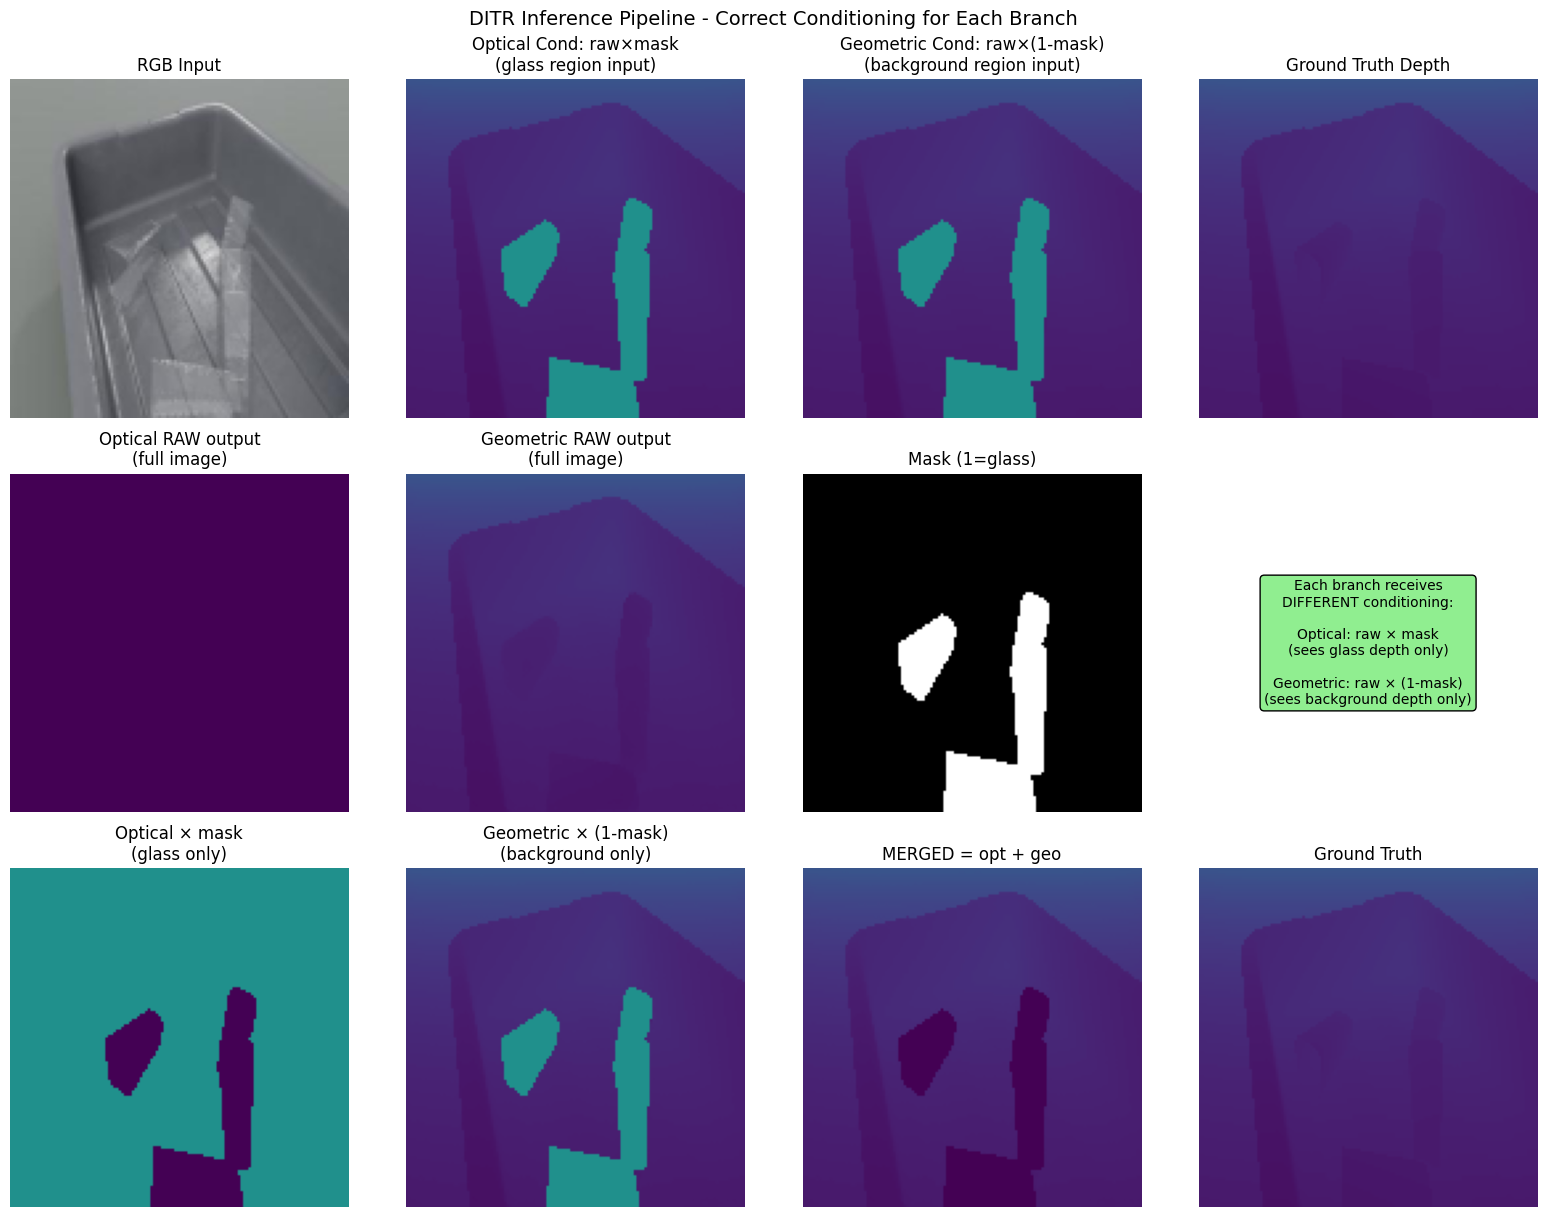

In [8]:
def run_ditr_inference_with_viz(opt_diff, geo_diff, batch_opt, batch_geo, device):
    """
    DITR inference following the pipeline:
    - Track A (Optical): generates inside mask (transparent area) using optical conditioning
    - Track B (Geometric): generates outside mask (background) using geometric conditioning
    - Merge: pred_opt * mask + pred_geo * (1 - mask)

    CRITICAL: Each branch must receive conditioning that matches its training:
    - Optical model trained with: RGB + (raw_depth * mask) + M_DA guidance
    - Geometric model trained with: RGB + (raw_depth * (1-mask)) + M_RGB guidance
    """
    opt_diff.model.eval()
    geo_diff.model.eval()

    # --- Prepare Data with CORRECT conditioning for each branch ---
    cond_opt = batch_opt["conditioning"].to(device)  # RGB + raw*mask + M_DA
    cond_geo = batch_geo["conditioning"].to(device)  # RGB + raw*(1-mask) + M_RGB

    # The optical mask: 1 = transparent/glass area
    mask = batch_opt["loss_mask"].to(device)  # 1 = glass

    # Ground truth depth (same for both)
    gt_depth = batch_opt["pixel_values"].to(device)

    # Extract RGB from optical conditioning for visualization
    rgb = cond_opt[:, :3, :, :]

    # Extract the raw depth channels for visualization
    raw_depth_opt = cond_opt[:, 3:4, :, :]  # raw * mask (glass only)
    raw_depth_geo = cond_geo[:, 3:4, :, :]  # raw * (1-mask) (background only)

    # Shape for sampling
    b, _, h, w = cond_opt.shape
    shape = (b, 1, h, w)

    print("Running Optical Branch with OPTICAL conditioning (raw*mask)...")
    # Optical model gets its own conditioning (raw depth masked to glass area)
    pred_opt_raw = opt_diff.sample(cond=cond_opt, shape=shape, device=device)

    print("Running Geometric Branch with GEOMETRIC conditioning (raw*(1-mask))...")
    # Geometric model gets its own conditioning (raw depth masked to background)
    pred_geo_raw = geo_diff.sample(cond=cond_geo, shape=shape, device=device)

    # --- Merge according to DITR pipeline ---
    # Optical output is valid INSIDE mask (glass area)
    # Geometric output is valid OUTSIDE mask (background)
    clean_opt = pred_opt_raw * mask           # Keep only glass region from optical
    clean_geo = pred_geo_raw * (1.0 - mask)   # Keep only background from geometric

    # Element-wise add (disjoint regions, no overlap)
    final_depth = clean_opt + clean_geo

    return {
        "pred_opt_raw": pred_opt_raw,      # Raw optical output (full image)
        "pred_geo_raw": pred_geo_raw,      # Raw geometric output (full image)
        "clean_opt": clean_opt,            # Optical masked (only glass region)
        "clean_geo": clean_geo,            # Geometric masked (only background)
        "merged": final_depth,             # Final merged output
        "mask": mask,                      # The mask (1=glass)
        "gt_depth": gt_depth,              # Ground truth depth
        "rgb": rgb,                        # RGB input
        "raw_depth_opt": raw_depth_opt,    # Raw depth for optical (glass only)
        "raw_depth_geo": raw_depth_geo,    # Raw depth for geometric (background only)
    }


# --- Visualization ---
def viz_all_results(results):
    """Visualize raw outputs, masked outputs, and final merge."""
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))

    def show(ax, tensor, title, cmap='viridis', vmin=-1, vmax=1):
        img = tensor[0, 0].cpu().numpy()
        im = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')
        return im

    def show_rgb(ax, tensor, title):
        img = tensor[0].cpu().numpy().transpose(1, 2, 0)
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(title)
        ax.axis('off')

    # Row 1: Input data - show both conditioning raw depths
    show_rgb(axes[0, 0], results["rgb"], "RGB Input")
    show(axes[0, 1], results["raw_depth_opt"], "Optical Cond: raw×mask\n(glass region input)")
    show(axes[0, 2], results["raw_depth_geo"], "Geometric Cond: raw×(1-mask)\n(background region input)")
    show(axes[0, 3], results["gt_depth"], "Ground Truth Depth")

    # Row 2: Raw model outputs (before masking)
    show(axes[1, 0], results["pred_opt_raw"], "Optical RAW output\n(full image)")
    show(axes[1, 1], results["pred_geo_raw"], "Geometric RAW output\n(full image)")
    show(axes[1, 2], results["mask"], "Mask (1=glass)", cmap='gray', vmin=0, vmax=1)
    axes[1, 3].axis('off')
    axes[1, 3].text(0.5, 0.5,
        "Each branch receives\n"
        "DIFFERENT conditioning:\n\n"
        "Optical: raw × mask\n"
        "(sees glass depth only)\n\n"
        "Geometric: raw × (1-mask)\n"
        "(sees background depth only)",
        ha='center', va='center', fontsize=10,
        transform=axes[1, 3].transAxes, bbox=dict(boxstyle='round', facecolor='lightgreen'))

    # Row 3: Masked outputs and merge
    show(axes[2, 0], results["clean_opt"], "Optical × mask\n(glass only)")
    show(axes[2, 1], results["clean_geo"], "Geometric × (1-mask)\n(background only)")
    show(axes[2, 2], results["merged"], "MERGED = opt + geo")
    show(axes[2, 3], results["gt_depth"], "Ground Truth")

    plt.tight_layout()
    plt.suptitle("DITR Inference Pipeline - Correct Conditioning for Each Branch", y=1.01, fontsize=14)
    plt.show()


# Run inference with CORRECT conditioning for each branch
with torch.no_grad():
    results = run_ditr_inference_with_viz(opt_diff, geo_diff, batch_opt, batch_geo, device)
    viz_all_results(results)